# Machine Learning Exercise 4
by Thanh Tran, Gero Brunke, Robin-Marcel Hanne

## Task 1

<div style="color: green; font-weight: bold">
Our implementation uses the projection vector `[-sin(θ), cos(θ)]`, while the sample solution uses `[cos(θ), -sin(θ)]`.
Our code is correct, since both vectors represent valid rotations depending on the chosen coordinate convention.

Our implementation casts projected values to integers early using `astype(np.int32)` after applying `floor`.
This is a potential robustness issue. Delaying integer conversion until after clipping (as in the sample solution) reduces the risk of floating-point precision errors near boundaries.

The coordinate grid is constructed manually using centered index arrays, whereas the sample solution uses a `mgrid`-based formulation.
This is a correct alternative implementation. Both approaches produce equivalent centered coordinate systems.


The loop over projection angles is structurally identical to the sample solution.

Our implementation computes separate validity masks for lower and upper interpolation contributions.
This is a minor inefficiency, since the sample solution uses a single clipping mask that is reused for both contributions. This reduces redundancy and slightly improves clarity and performance.
</div>

In [1]:
import numpy as np
from scipy.sparse import coo_matrix
import matplotlib.pyplot as plt
from scipy.sparse.linalg import lsqr

In [2]:
def construct_X(M, alphas, Np=None):
    alphas = np.asarray(alphas)
    No = len(alphas)

    if Np is None:
        Np = int(np.ceil(np.sqrt(2) * M))
        if Np % 2 == 0:
            Np += 1

    D = M * M
    N = No * Np

    center = (M - 1) / 2

    ja, jb = np.mgrid[0:M, 0:M]
    a = ja - center
    b = jb - center

    C = np.vstack([a.ravel(), b.ravel()])
    pixels = np.arange(D)

    s0 = (Np - 1) / 2

    i_indices = []
    j_indices = []
    weights = []

    for io, alpha in enumerate(alphas):

        theta = np.deg2rad(alpha)

        n = np.array([-np.sin(theta), np.cos(theta)])

        p = n @ C + s0

        k = np.floor(p).astype(np.int32)
        w = p - k

        offset = io * Np

        m1 = (k >= 0) & (k < Np)
        i_indices.append(offset + k[m1])
        j_indices.append(pixels[m1])
        weights.append((1 - w[m1]).astype(np.float32))

        m2 = (k + 1 >= 0) & (k + 1 < Np)
        i_indices.append(offset + k[m2] + 1)
        j_indices.append(pixels[m2])
        weights.append(w[m2].astype(np.float32))

    i_indices = np.concatenate(i_indices)
    j_indices = np.concatenate(j_indices)
    weights = np.concatenate(weights)

    return coo_matrix((weights, (i_indices, j_indices)), shape=(N, D), dtype=np.float32)

In [3]:
folder = "hs_tomography/"

y_77 = np.load(folder + "y_77.npy")
alphas_77 = np.load(folder + "alphas_77.npy")

y_195 = np.load(folder + "y_195.npy")
alphas_195 = np.load(folder + "alphas_195.npy")

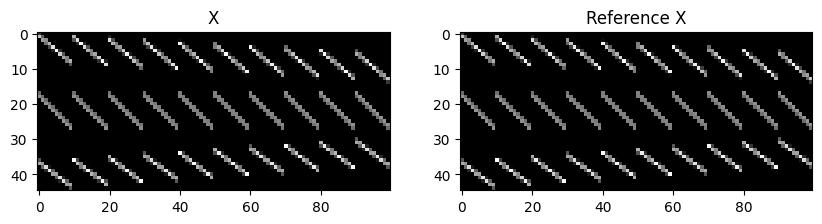

In [4]:
X_test = construct_X(10, [-33, 1, 42])
X_ref = np.load(folder + "X_example.npy")

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("X")
plt.imshow(X_test.toarray(), cmap="gray")

plt.subplot(1,2,2)
plt.title("Reference X")
plt.imshow(X_ref, cmap="gray")

plt.show()

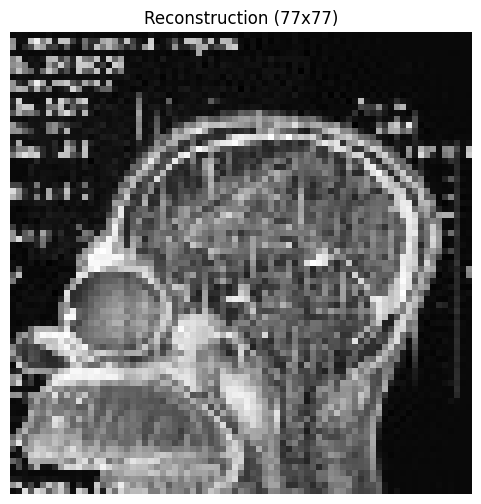

In [5]:
X_77 = construct_X(77, alphas_77, Np=109)

beta_77 = lsqr(X_77.tocsc(), y_77)[0]
img_77 = beta_77.reshape((77, 77))

plt.figure(figsize=(6,6))
plt.imshow(img_77, cmap="gray")
plt.title("Reconstruction (77x77)")
plt.axis("off")
plt.show()

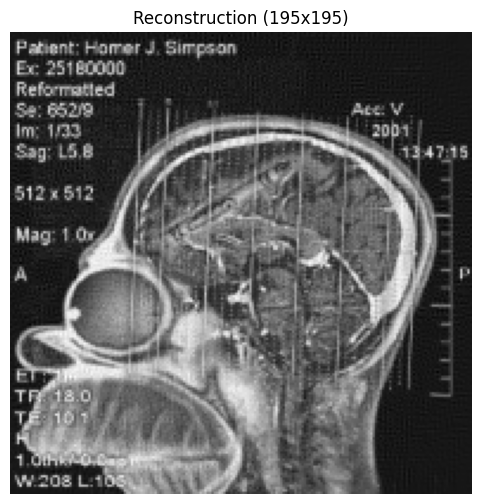

In [6]:
X_195 = construct_X(195, alphas_195, Np=275)

beta_195 = lsqr(X_195.tocsc(), y_195)[0]
img_195 = beta_195.reshape((195, 195))

plt.figure(figsize=(6,6))
plt.imshow(img_195, cmap="gray")
plt.title("Reconstruction (195x195)")
plt.axis("off")
plt.show()

## Task 2

### Sparsity and Optimization

In [7]:
nnz_195 = X_195.nnz
total_elements = X_195.shape[0] * X_195.shape[1]
sparsity = 1.0 - (nnz_195 / total_elements)

print(f"Matrix shape {X_195.shape}")
print(f"Non-Zero Entires count: {nnz_195}")
print(f"Sparsity of X: {sparsity:.4%} of the matrix are zero")


Matrix shape (49225, 38025)
Non-Zero Entires count: 13612930
Sparsity of X: 99.2727% of the matrix are zero


Shape of beta 195: (38025,)


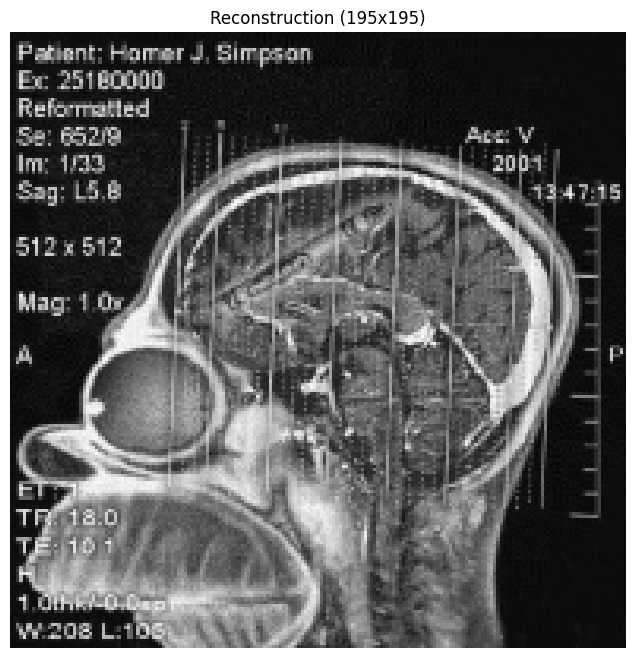

In [8]:
tolerance = 1e-08 # set to 1e-05 for faster computing, but we validated it before and it seems to make sense, so low tolerance version :)

beta_195 = lsqr(X_195.tocsc(), y_195, atol=tolerance, btol=tolerance)[0]
print(f"Shape of beta 195: {beta_195.shape}")
img_195 = beta_195.reshape((195, 195))


plt.figure(figsize=(8, 8))
plt.imshow(img_195, cmap="gray")
plt.title("Reconstruction (195x195)")
plt.axis("off")
plt.show()

### Diagnosis

Mr Simpson seems to have what is either a crayon, pen or stick like object stuck in his crayon. My suggestion: surgical removal via nosal cavity.

# Task 3

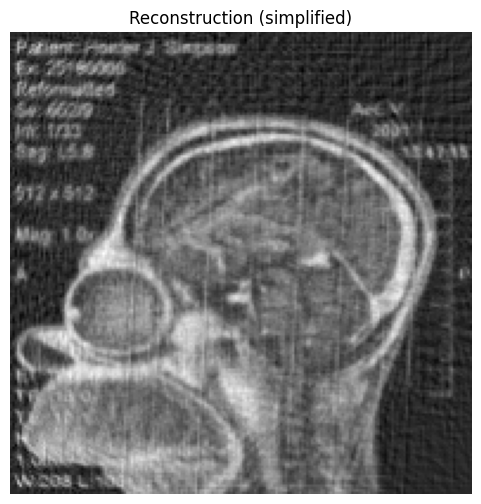

In [25]:
deltaAngle = 3 # in degrees (every angle from (0, deltaAngle, 2*deltaAngle,..., 360)


alphas = np.load(folder + "alphas_195.npy")
alpha_spacing = np.mean(np.diff(alphas))
steps = max(1, int(round(deltaAngle / alpha_spacing)))

M = 195
Np = 275
y = np.load(folder + "y_195.npy")
alphas_sub = alphas[::steps]

y_sino = y.reshape(len(alphas), Np)
y_sub = y_sino[::steps].ravel()

X_sub = construct_X(M, alphas_sub, Np)

beta_sub = lsqr(X_sub.tocsc(), y_sub,
                atol=1e-5, btol=1e-5)[0]

img = beta_sub.reshape((M, M))

plt.figure(figsize=(6,6))
plt.imshow(img, cmap="gray")
plt.title("Reconstruction (simplified)")
plt.axis("off")
plt.show()

Comparing the image to the sharp image from task 2, using a difference of deltaAngle=3 between consecutive angles would approximately use just a third of radiation dose while still yielding an image where one could see that a crayon-like object is stuck in the brain. Using any deltaAngle > 5 is too large to make any reasonable assumption about H.S. condition, the sweetspot is 3 (4 still yields a somewhat good result if you know what you were looking for, but for a real case scenario that would result in a too fuzzy image).